# 04 - Random Forest Classification

This notebook trains and tunes a Random Forest classifier for loan approval prediction, evaluates it on the test set, plots the key metrics, and saves the best model for reuse.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

BASE_DIR = Path('..').resolve()
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOTS_DIR = BASE_DIR / 'plots' / 'classification'
MODELS_DIR = BASE_DIR / 'models'
for folder in [PLOTS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze('columns')

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
TARGET_COL = 'LoanApproved'
RANDOM_STATE = 42

X_train shape: (8000, 34)
X_test shape: (2000, 34)
y_train shape: (8000,)
y_test shape: (2000,)


## Hyperparameter tuning
A RandomizedSearchCV sweep is used to tune the Random Forest depth and tree structure.

In [2]:
base_model = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=5,
    cv=2,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print('Best parameters:', search.best_params_)
print('Best cross-validation score:', round(search.best_score_, 4))

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 10}
Best cross-validation score: 0.8194


## Evaluation
The tuned model is evaluated on the held-out test set using standard classification metrics and diagnostic curves.

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1511
           1       0.79      0.86      0.82       489

    accuracy                           0.91      2000
   macro avg       0.87      0.89      0.88      2000
weighted avg       0.91      0.91      0.91      2000

ROC-AUC: 0.9718
PR-AUC: 0.9227


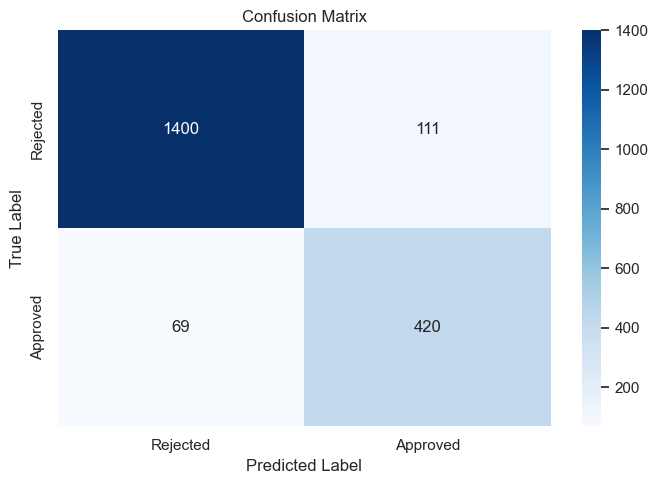

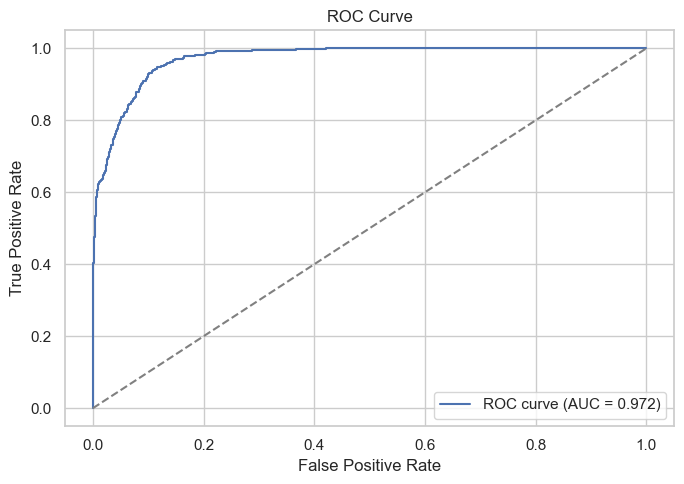

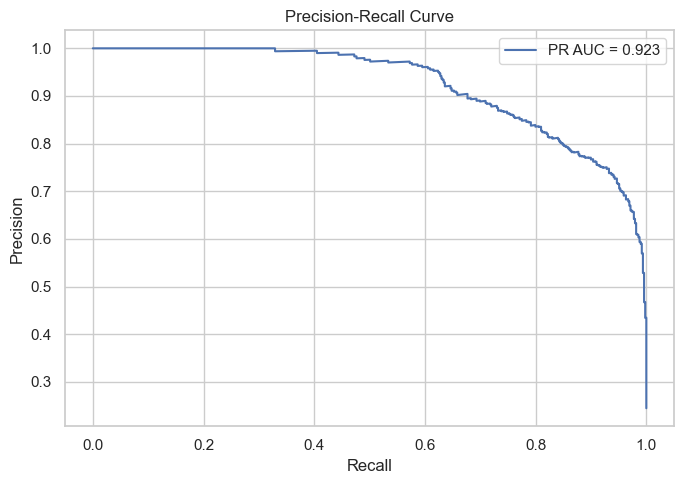

In [3]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.predict(X_test)

print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print('ROC-AUC:', round(roc_auc, 4))
print('PR-AUC:', round(pr_auc, 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Feature importance
The most influential features are shown as a top-15 bar chart.

C:\Users\Aachal Shrestha\AppData\Local\Temp\ipykernel_11280\2792143187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')


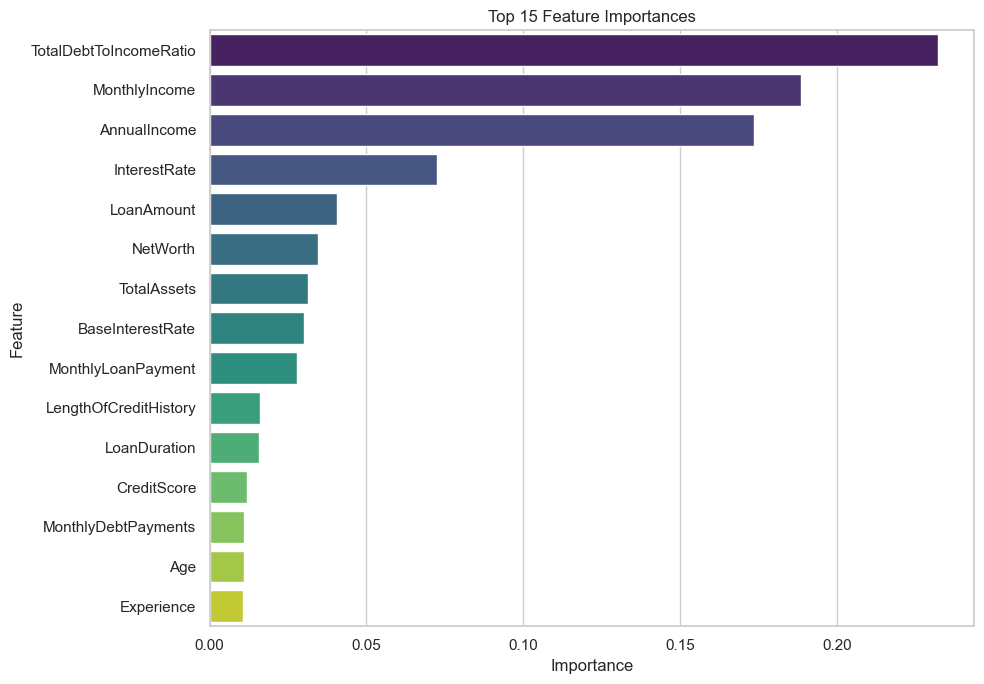

Best model saved to D:\Financial-Risk-Classification-and-Behavioral-Pattern-Clustering\models\random_forest_model.pkl
Classification complete.


In [4]:
feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

joblib.dump(best_model, MODELS_DIR / 'random_forest_model.pkl')
print('Best model saved to', MODELS_DIR / 'random_forest_model.pkl')
print('Classification complete.')